In [1]:
from __future__ import print_function
import sys, os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import ROOT
from ROOT import gROOT, gStyle, gDirectory, gPad

import filepath 
import portROOT2pd
from pdgid import pdgid_dict
import plot_utils
import constants

geometry = "stm_mod1"
tags = ["Ele", "Mu", "1809"]
pklname = geometry+".pkl"


In [2]:
#df = pd.DataFrame()
#for tag in tags:
#    fileList_ = filepath.getrootlist(geometry, tag)
#    df_ = portROOT2pd.PortToDF(geometry, tag, fileList_, True, None)
#    df = pd.concat([df,df_], ignore_index=True)
#with open(pklname, 'wb') as f:
#    pickle.dump(df, f)

In [3]:
with open(pklname, 'rb') as f:
    df = pickle.load(f)
#df = df.query("virtualdetectorId==101").reset_index()

In [4]:
print("z coordinates of events:", np.sort(df['z'].unique()))
print("weights:", np.sort(df['weight'].unique()))
print("x range: [%.3lf, %.3lf]"%(np.min(df['x'].unique()),np.max(df['x'].unique())))
print("y range: [%.3lf, %.3lf]"%(np.min(df['y'].unique()),np.max(df['y'].unique())))
print("r range: [%.3lf, %.3lf]"%(np.min(df['r'].unique()),np.max(df['r'].unique())))
print("VDs:", np.sort(df['virtualdetectorId'].unique()))
display(df)

z coordinates of events: [40185.38       40185.38       40185.39930169 40185.4       ]
weights: [ 0.10056167  1.00548834 41.15716125]
x range: [-99.985, 99.981]
y range: [-99.544, 100.258]
r range: [0.179, 100.412]
VDs: [101]


,tag,time,virtualdetectorId,pdgId,x,y,z,E,r,weight
0,Ele,231.810140,101,11,-79.115602,21.857691,40185.38,995.315843,82.079456,41.157161
1,Ele,231.984643,101,11,-87.381964,24.715060,40185.40,853.825396,90.809921,41.157161
2,Ele,231.571741,101,22,-27.044214,68.579431,40185.38,3953.349993,73.719250,41.157161
3,Ele,176.234048,101,22,-92.831299,-13.137950,40185.38,29004.284327,93.756364,41.157161
4,Ele,266.663956,101,22,24.980331,89.180141,40185.38,466.300984,92.612712,41.157161
...,...,...,...,...,...,...,...,...,...,...
70412,1809,1230.506097,101,22,75.304583,-50.635881,40185.38,1809.000000,90.745649,0.100562
70413,1809,1867.560569,101,22,70.867443,-44.680442,40185.38,1809.000000,83.776706,0.100562
70414,1809,526.994940,101,22,57.442214,21.085862,40185.38,1809.000000,61.190044,0.100562
70415,1809,1483.380023,101,22,-17.061308,95.269194,40185.38,1809.000000,96.784852,0.100562



$e^{+}$ from Ele:  105
$e^{-}$ from Ele:  7134
$\gamma$ from Ele:  35886
$n$ from Ele:  47

$e^{+}$ from Mu:  68
$e^{-}$ from Mu:  3520
$\gamma$ from Mu:  20983
$n$ from Mu:  2640
$p$ from Mu:  1


/exp/mu2e/data/users/yongyiwu/stm_analysis/plot_utils.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(4,3))



$e^{-}$ from 1809:  1
$\gamma$ from 1809:  32


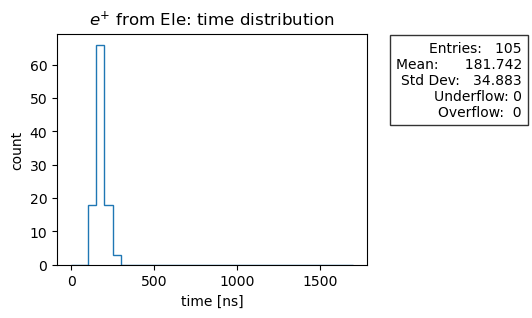

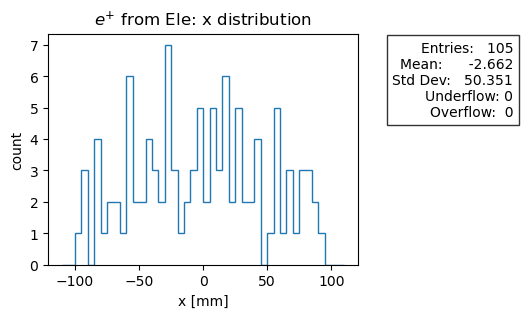

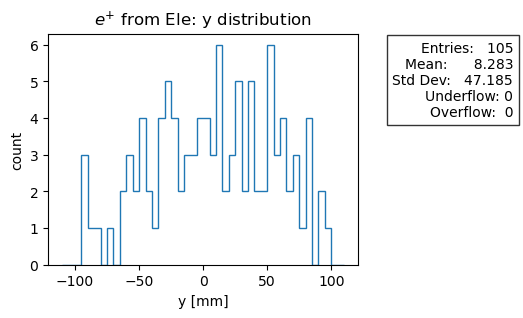

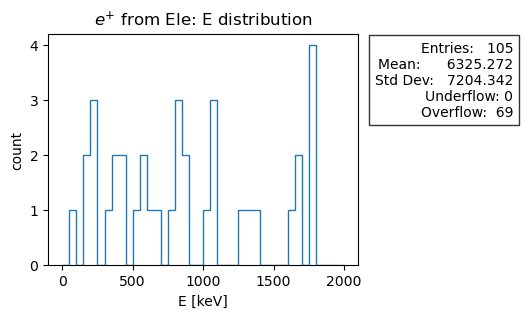

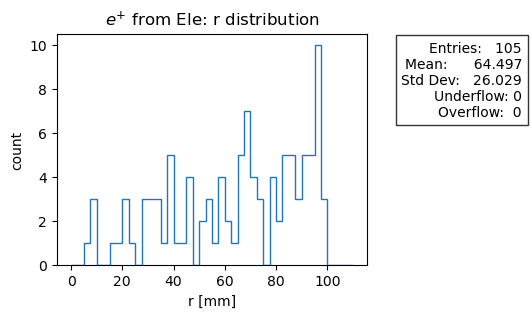

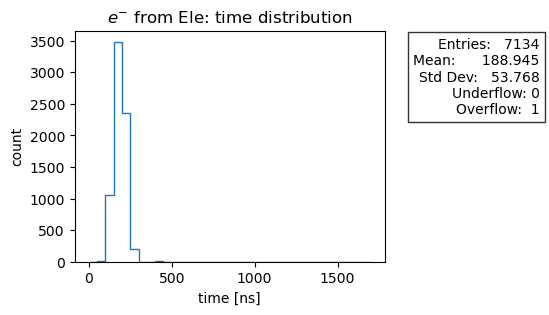

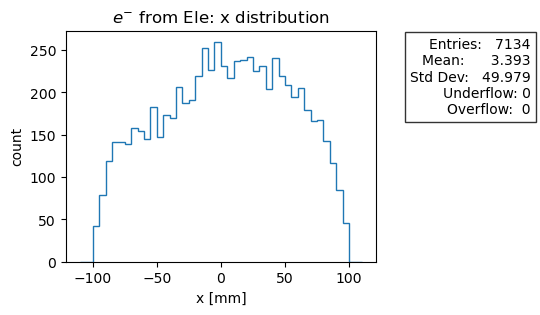

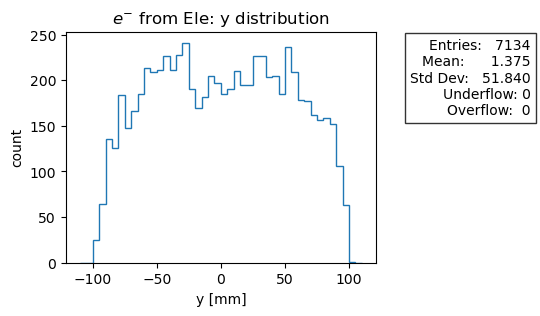

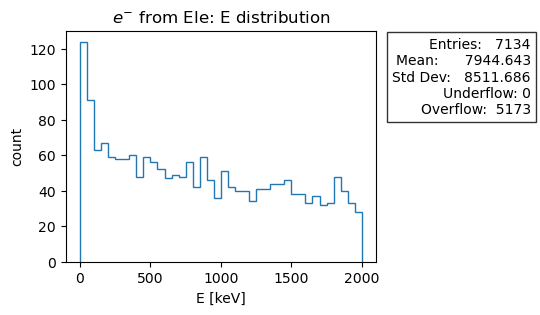

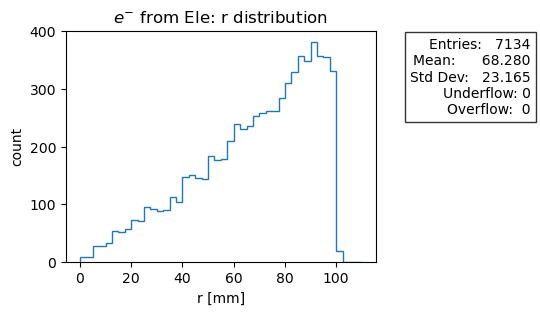

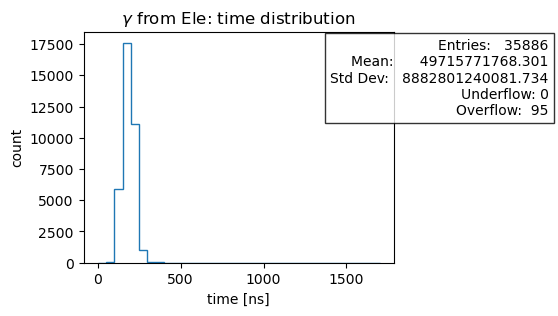

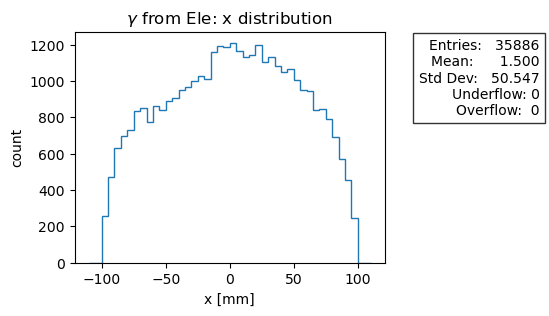

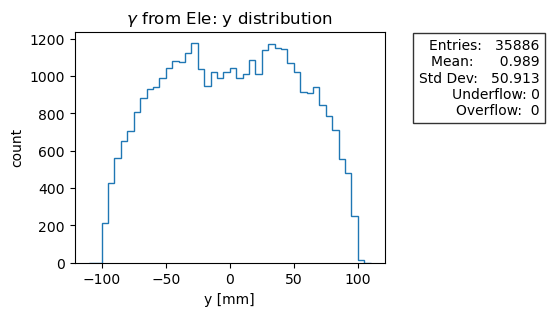

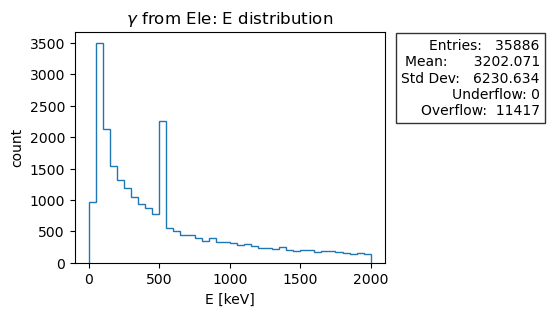

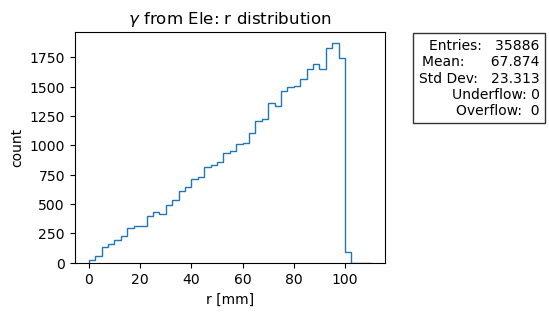

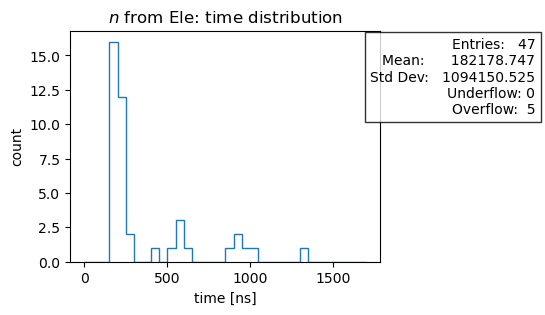

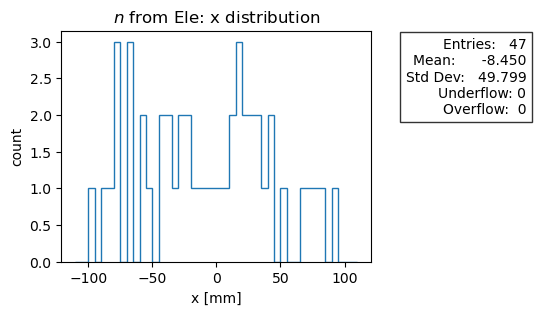

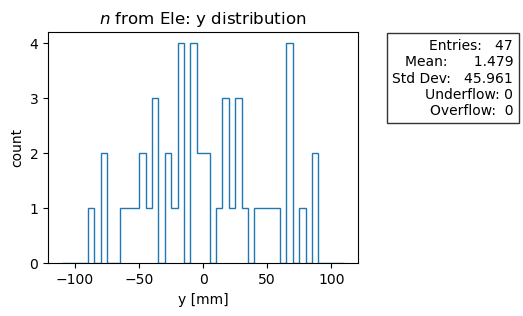

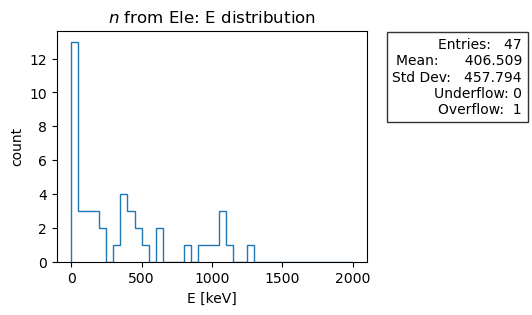

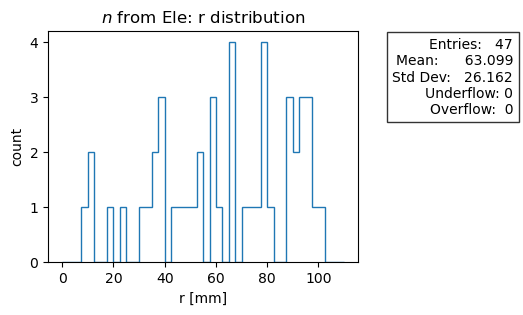

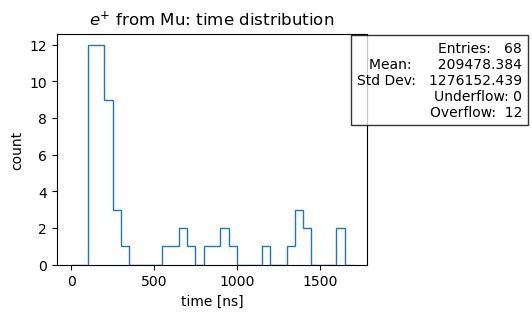

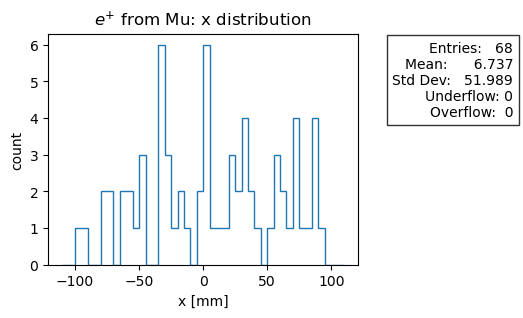

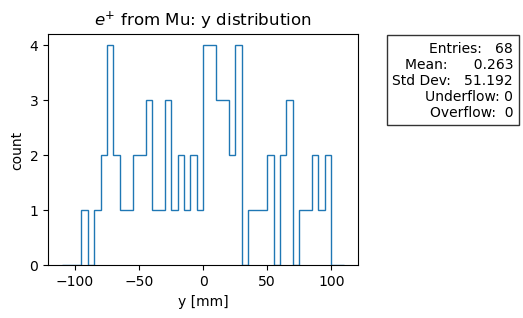

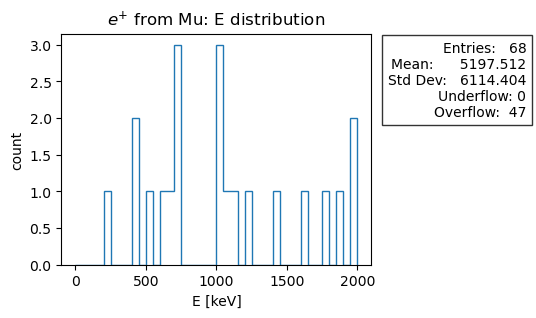

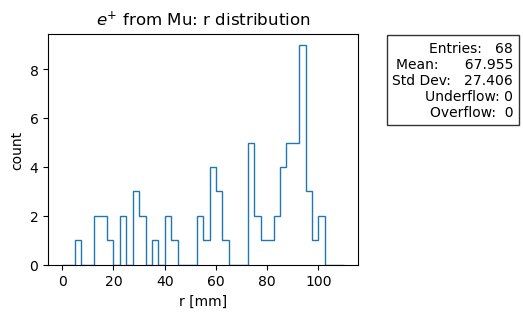

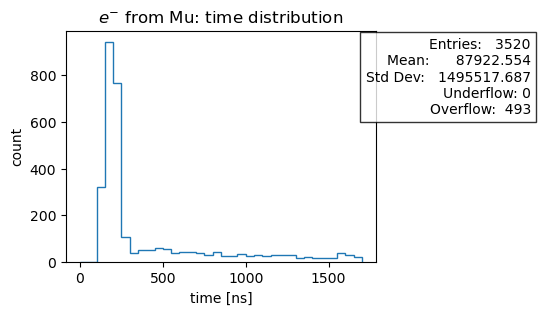

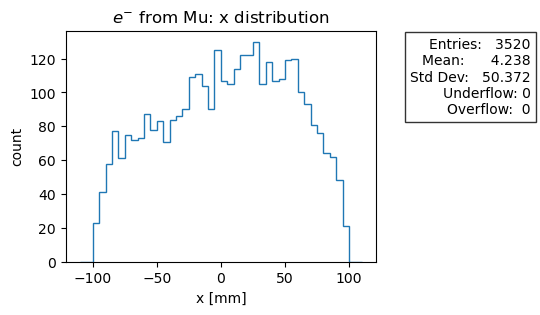

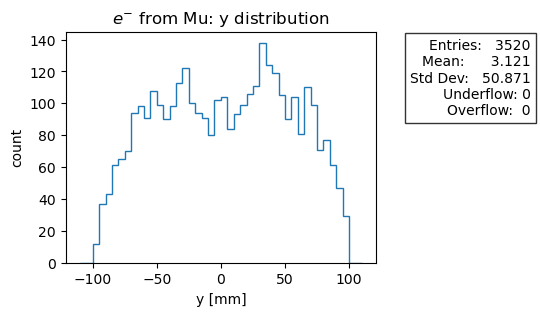

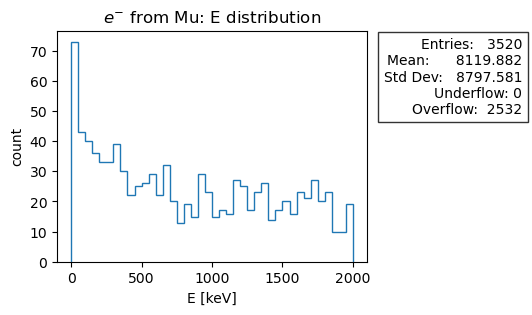

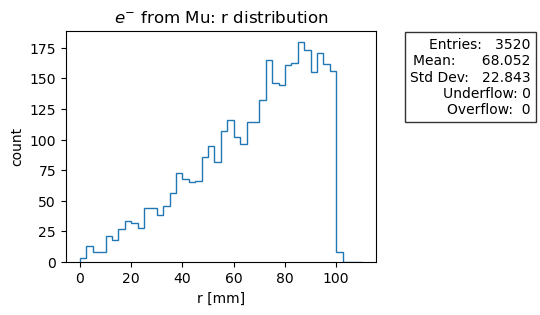

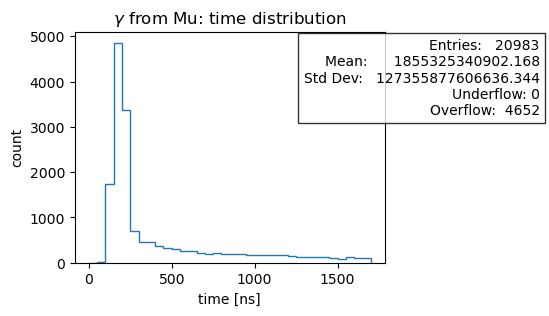

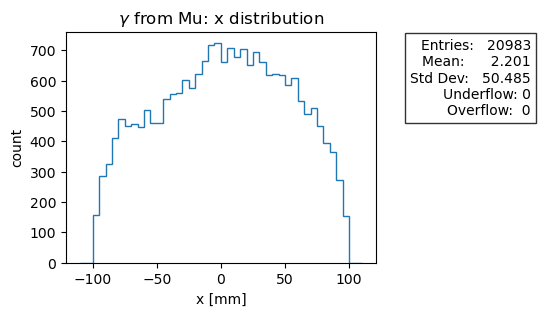

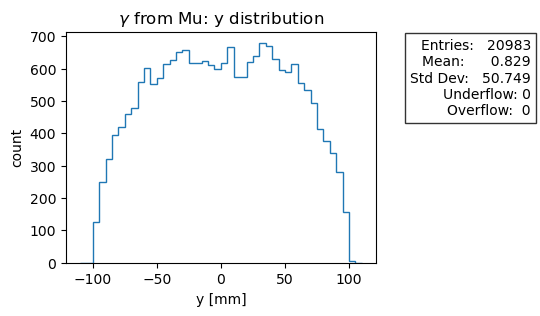

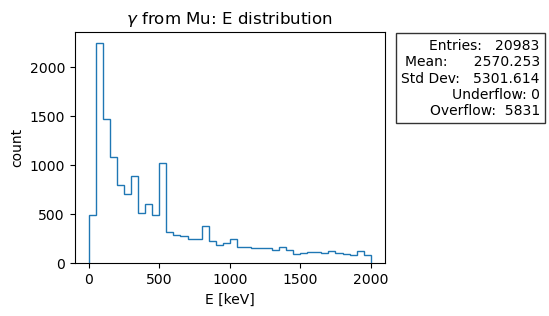

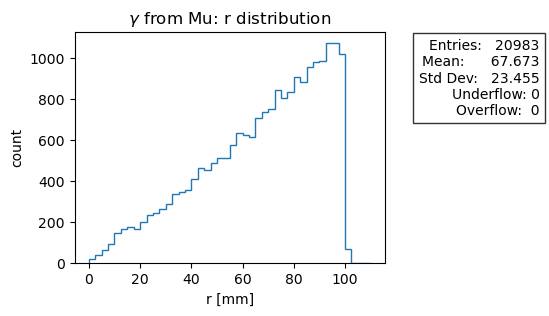

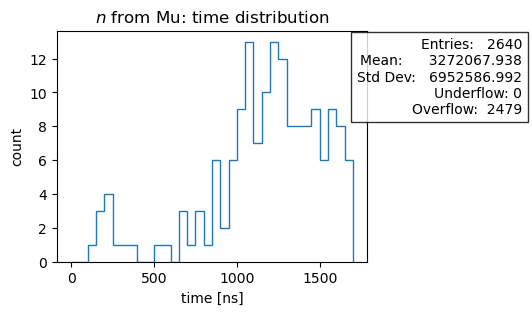

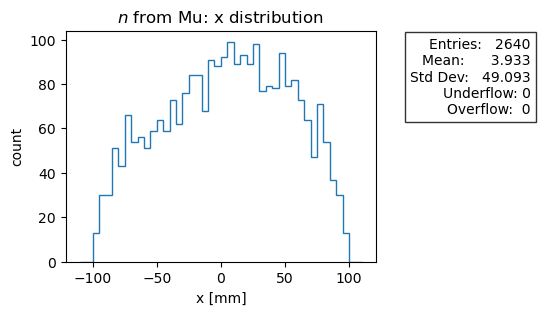

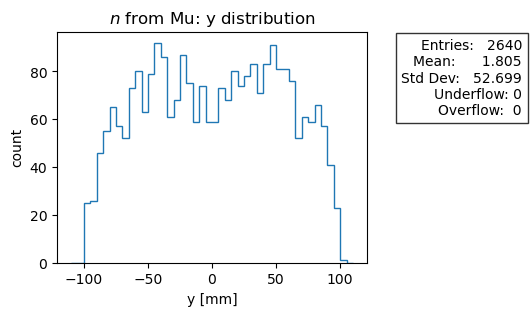

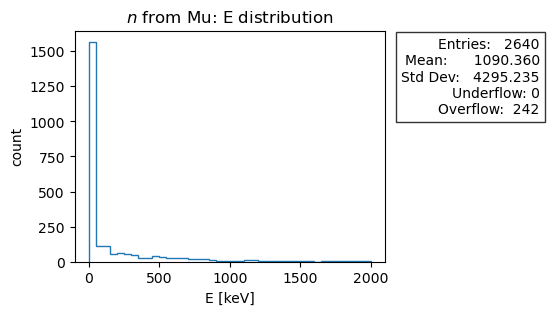

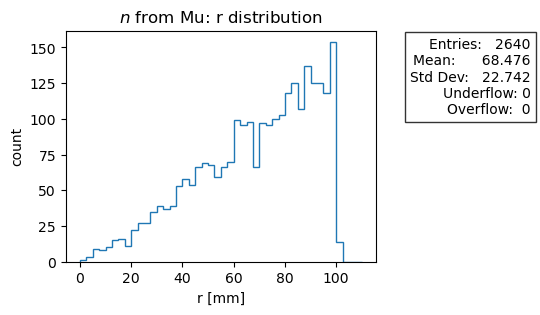

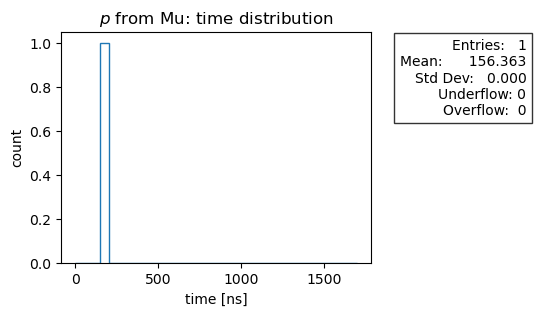

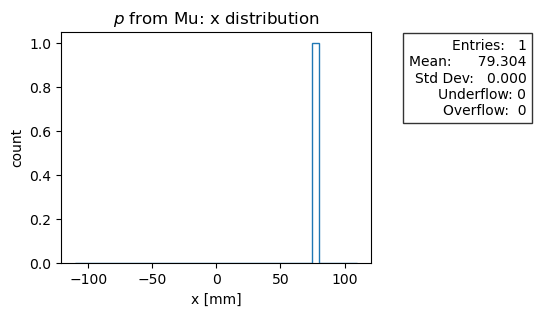

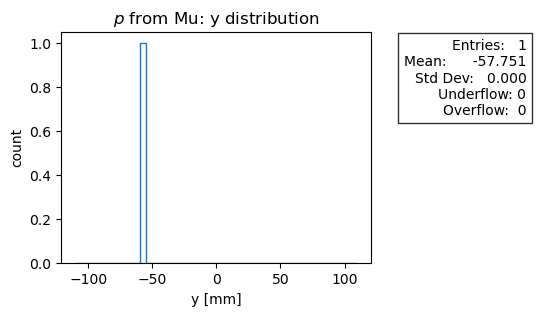

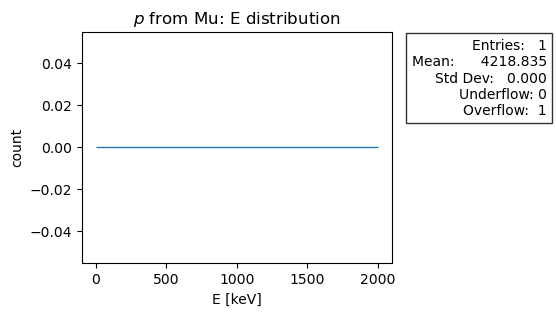

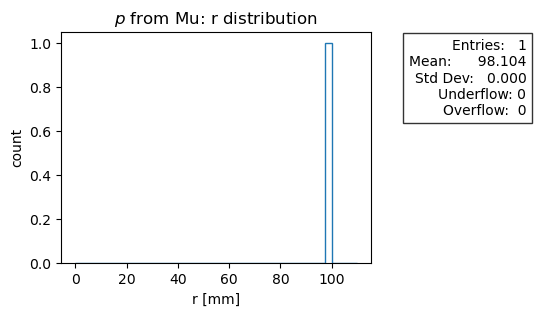

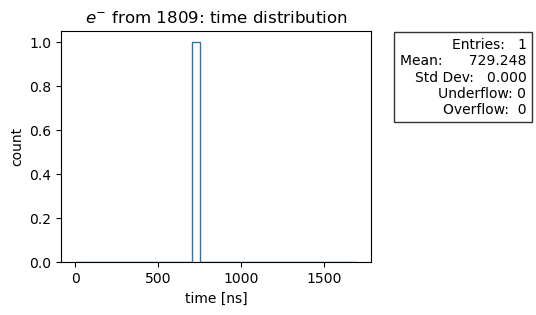

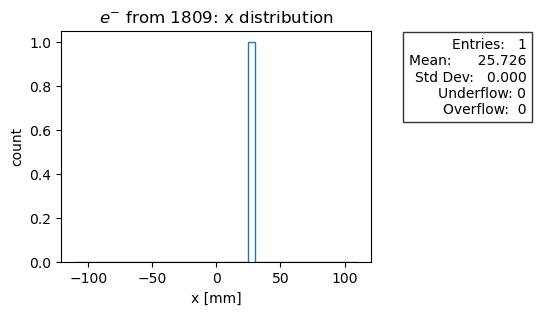

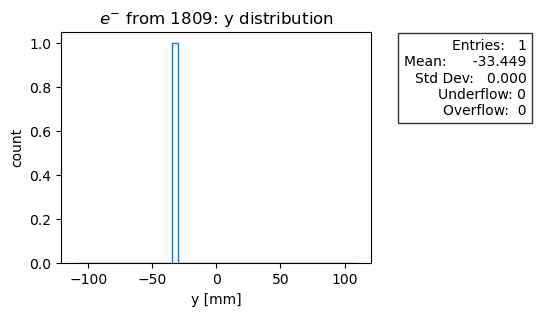

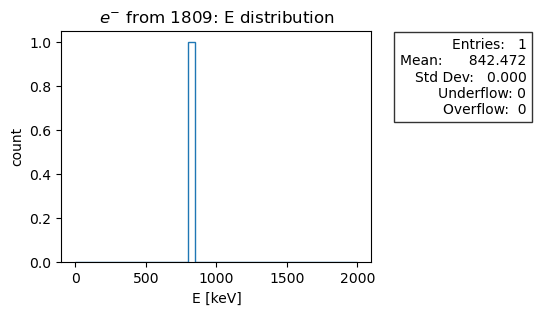

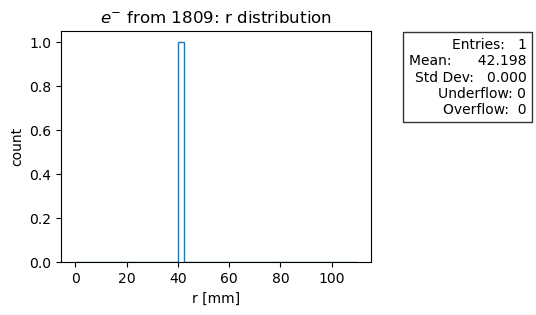

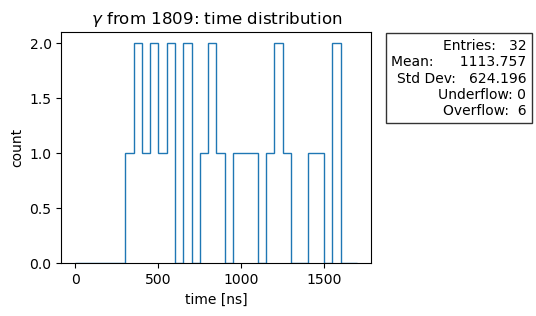

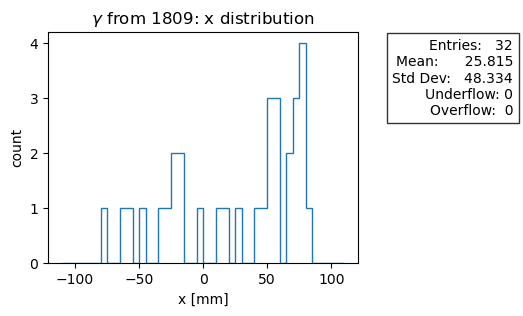

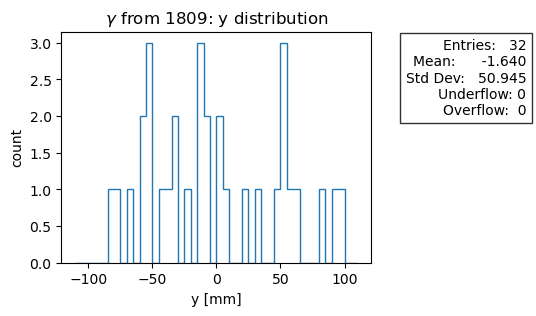

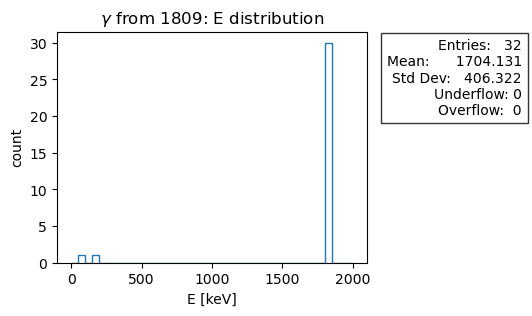

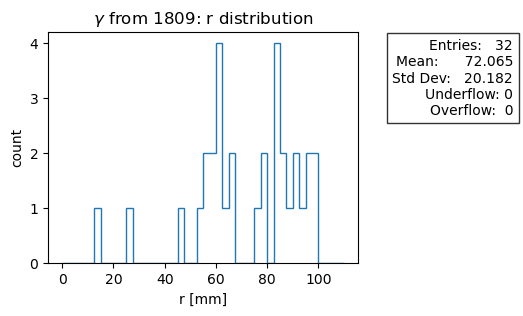

In [5]:
item_list = ['time', 'x', 'y', 'E', 'r']
title_list = [item+' distribution' for item in item_list]
xlabel_list = ['time [ns]', 'x [mm]', 'y [mm]', 'E [keV]', 'r [mm]']
ylabel_list = ['count' for item in item_list]

for tag in tags:
    print("")
    df_ = df.query("tag==@tag").reset_index()
    list_of_pdgId = np.sort(df_['pdgId'].unique())
    for pdgId in list_of_pdgId:
        mydf = df_.query("pdgId==%i"%(pdgId)).reset_index()
        group_name = pdgid_dict[pdgId]+' from '+tag+': '
        print(group_name, len(mydf))
        for index, item in enumerate(item_list):
            fig, ax = plot_utils.single_hist(mydf, item, [group_name+title_list[index], xlabel_list[index], ylabel_list[index]])
            

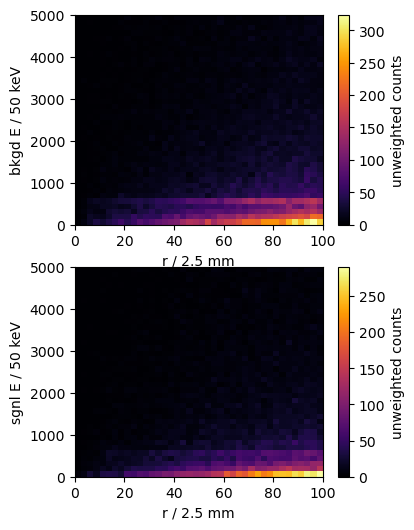

In [6]:
fig, ax = plot_utils.twod_hist(df, 'r', 'E', "")

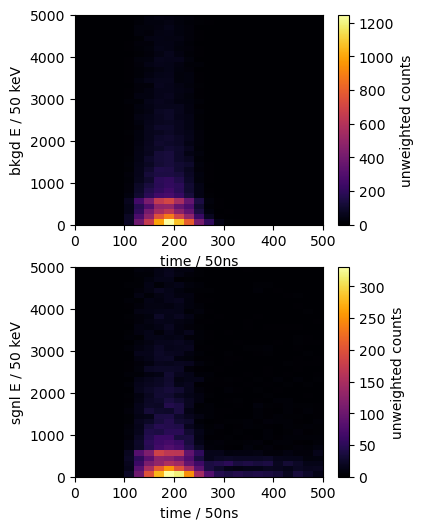

In [7]:
fig, ax = plot_utils.twod_hist(df, 'time', 'E', "")

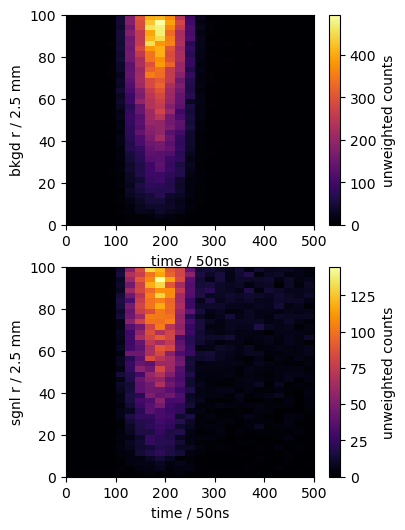

In [8]:
fig, ax = plot_utils.twod_hist(df, 'time', 'r', "")

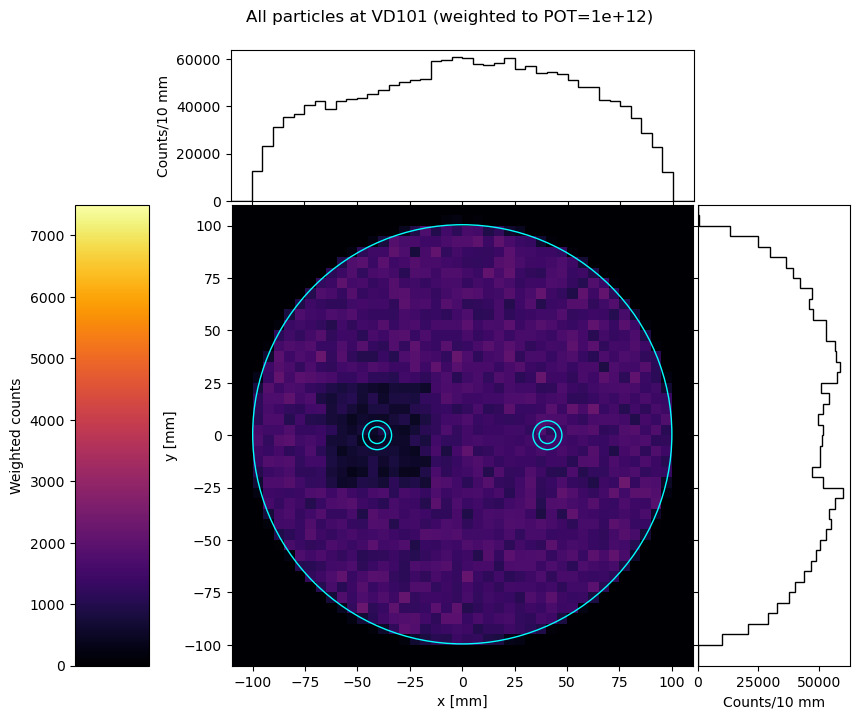

In [9]:
fig, ax2d, axX, axY = plot_utils.particle_space_dist(df, "All particles at VD101 (weighted to POT=%.0e)"%int(filepath.goal_POT), constants.XYmaxbincount)

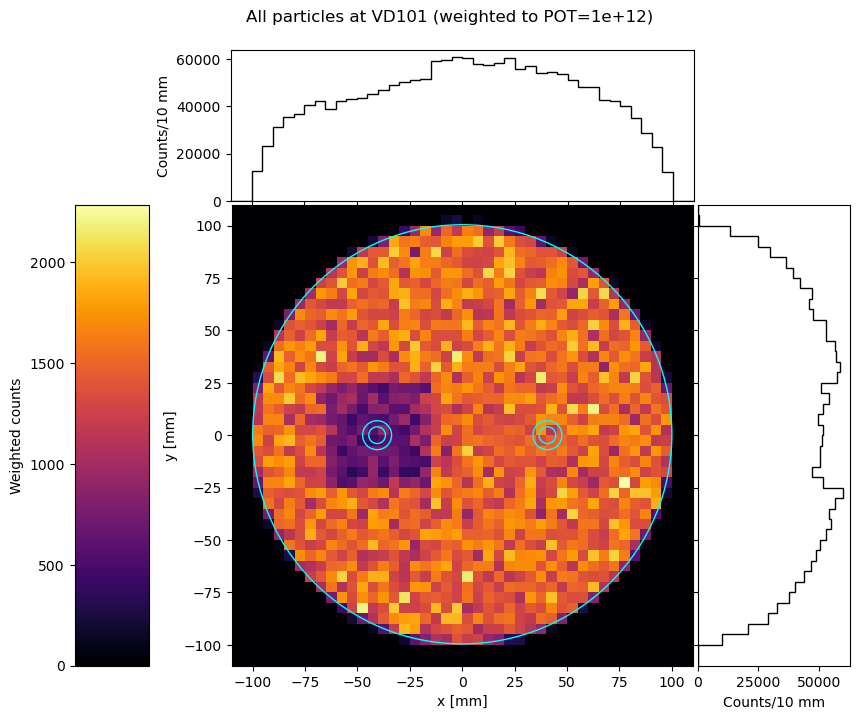

In [10]:
fig, ax2d, axX, axY = plot_utils.particle_space_dist(df, "All particles at VD101 (weighted to POT=%.0e)"%int(filepath.goal_POT))

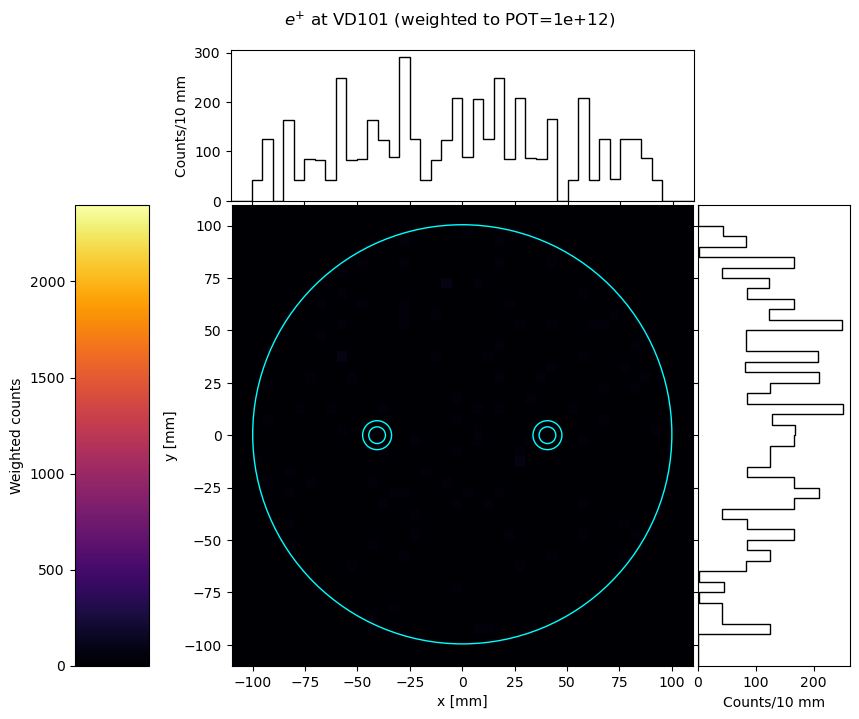

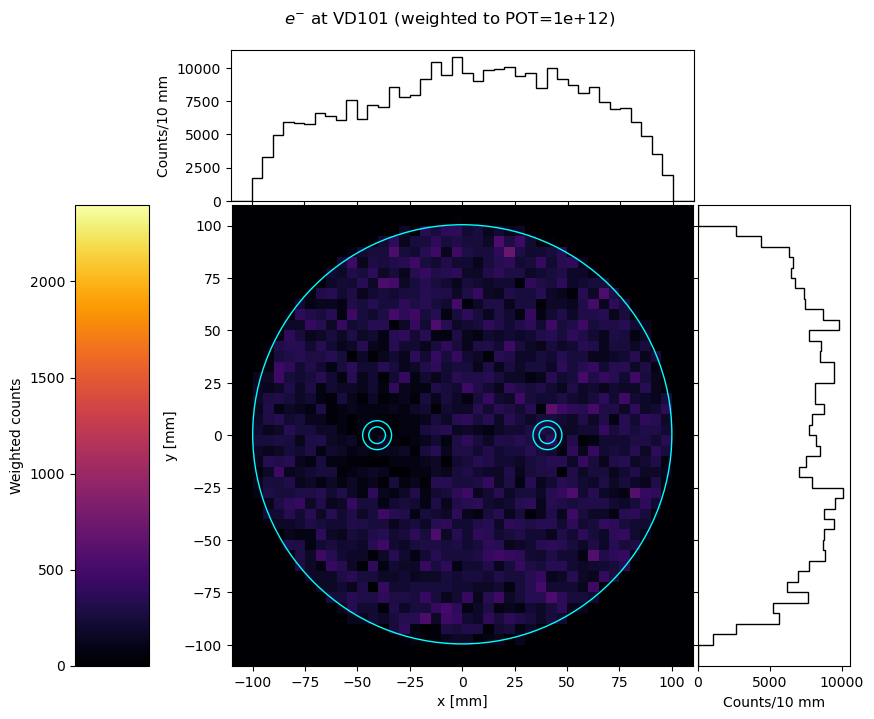

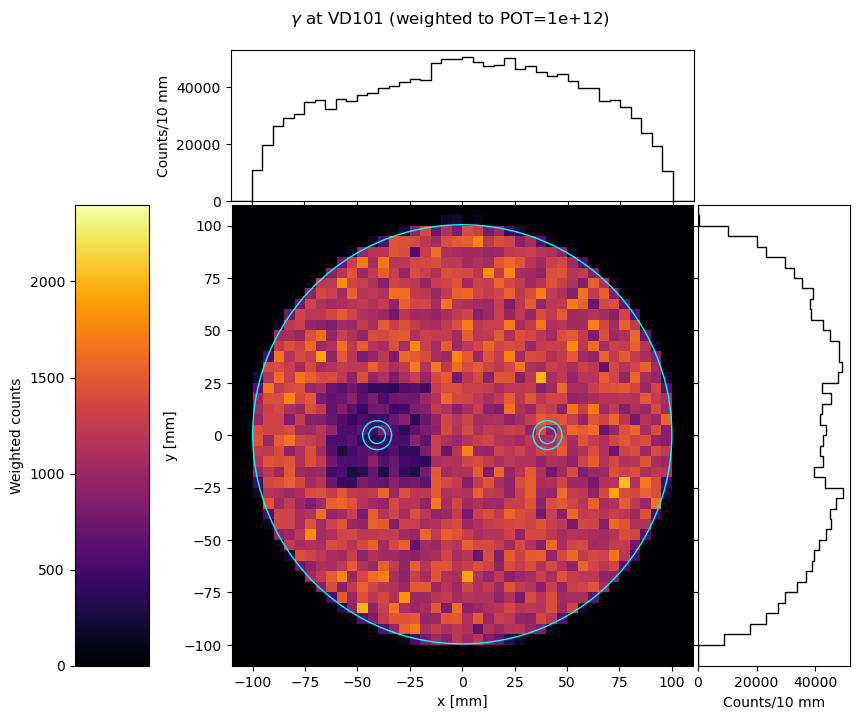

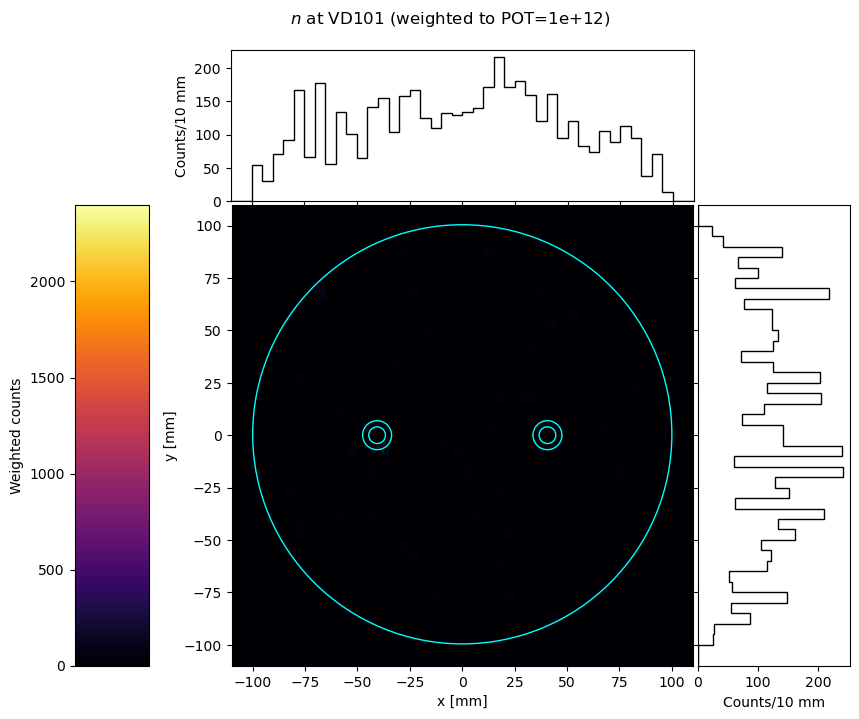

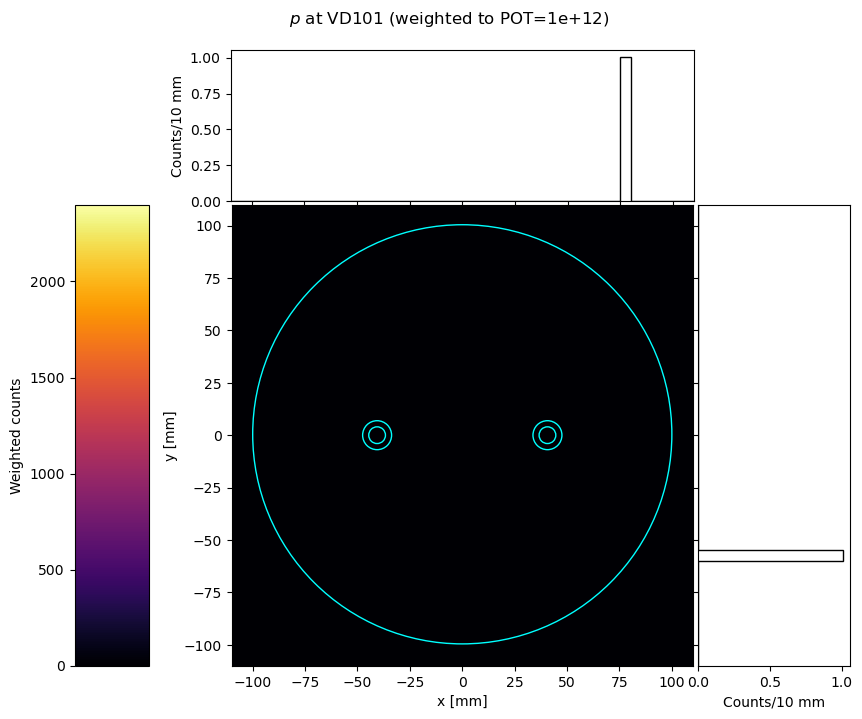

In [11]:
list_of_pdgId = np.sort(df['pdgId'].unique())
for pdgId in list_of_pdgId:
    mydf = df.query("pdgId==%i"%(pdgId)).reset_index()
    fig, ax2d, axX, axY = plot_utils.particle_space_dist(mydf, pdgid_dict[pdgId]+" at VD101 (weighted to POT=%.0e)"%int(filepath.goal_POT), 2400) 
    plt.show()

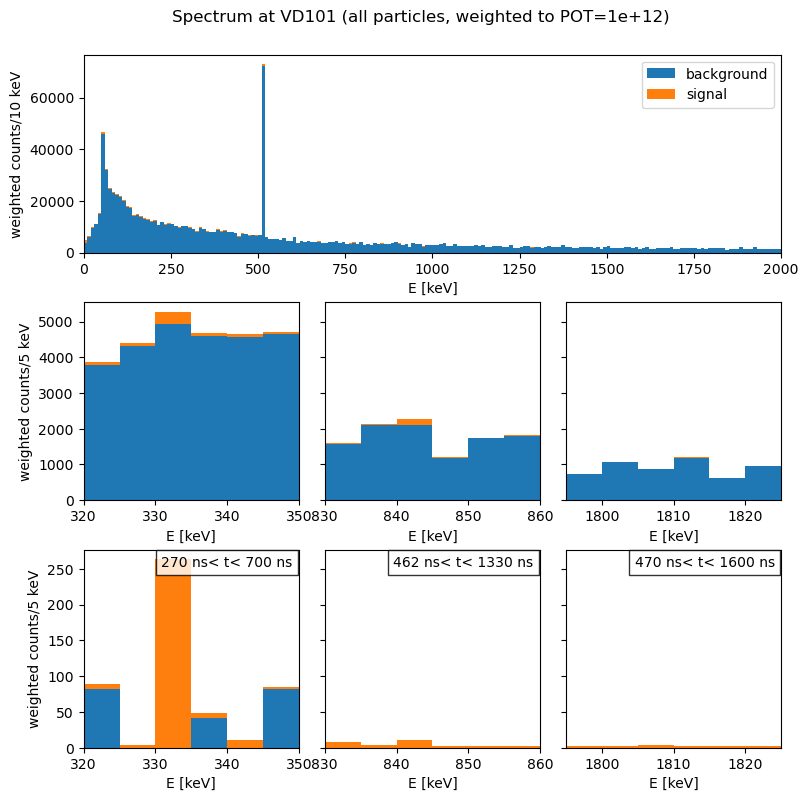

In [12]:
fig, ax = plot_utils.spectra_stacked_sgnl_bkgd(df, "Spectrum at VD101 (all particles, weighted to POT=%.0e)"%int(filepath.goal_POT))#, constants.spectramaxbincount)

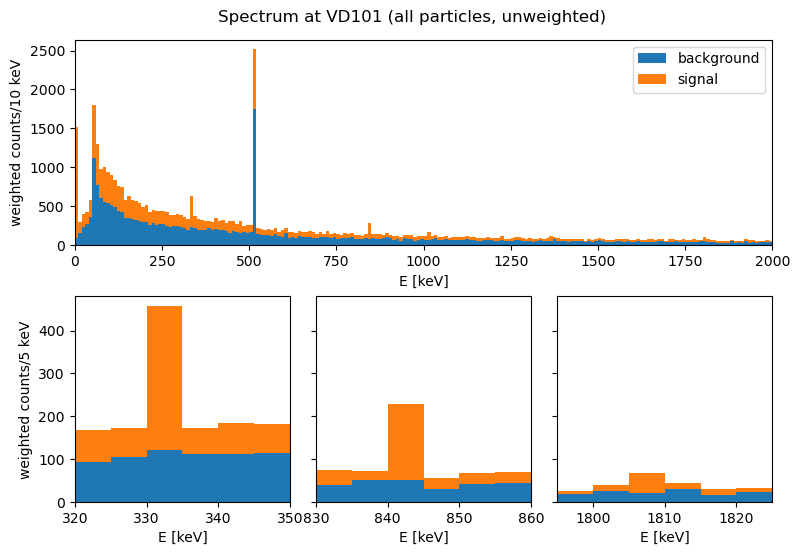

In [13]:
fig, ax = plot_utils.spectra_stacked_sgnl_bkgd(df, "Spectrum at VD101 (all particles, unweighted)", None, False)

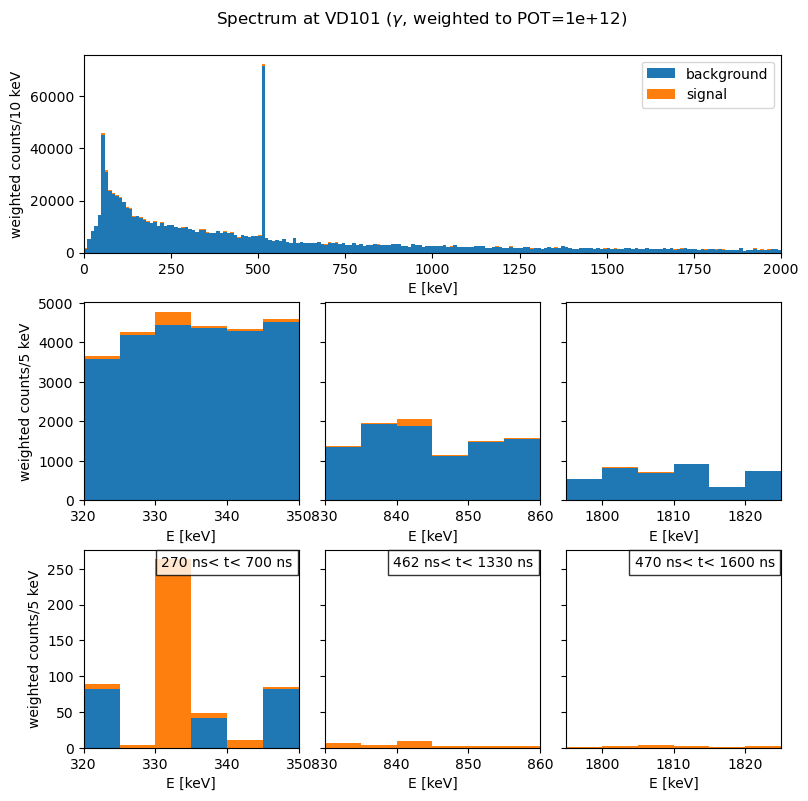

In [14]:
df_gamma = df.query("pdgId==22").reset_index()
fig, ax = plot_utils.spectra_stacked_sgnl_bkgd(df_gamma, r"Spectrum at VD101 ($\gamma$, weighted to POT=%.0e)"%int(filepath.goal_POT))#, constants.spectramaxbincount)

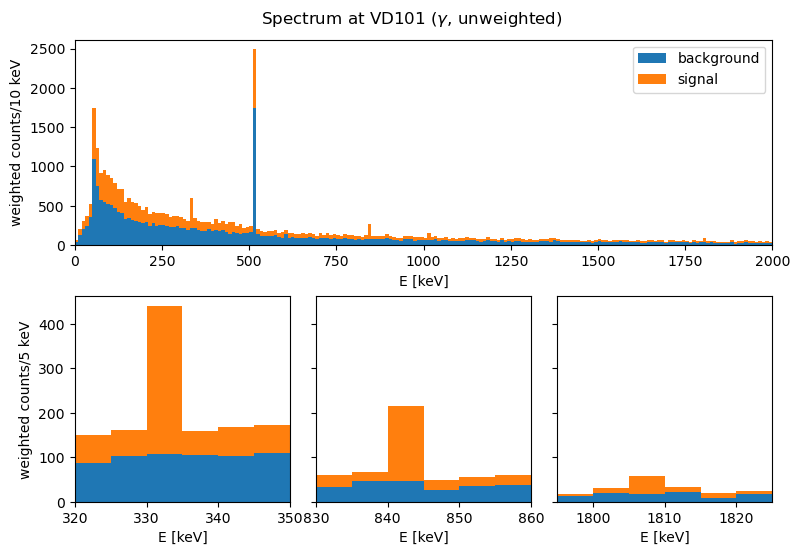

In [15]:
fig, ax = plot_utils.spectra_stacked_sgnl_bkgd(df_gamma, r"Spectrum at VD101 ($\gamma$, unweighted)", None, False)

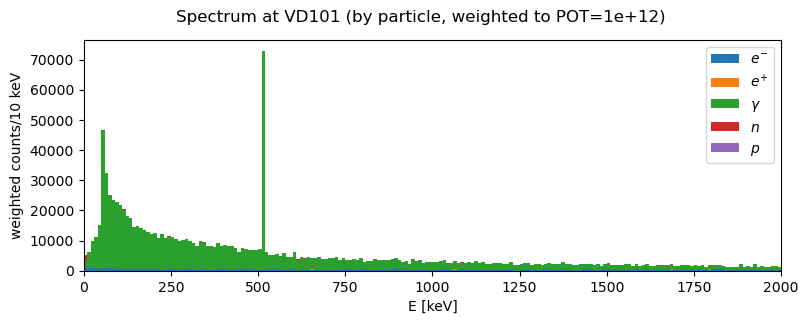

In [16]:
fig, ax = plot_utils.spectra_stacked_particle(df, "Spectrum at VD101 (by particle, weighted to POT=%.0e)"%int(filepath.goal_POT))#, constants.spectramaxbincount)

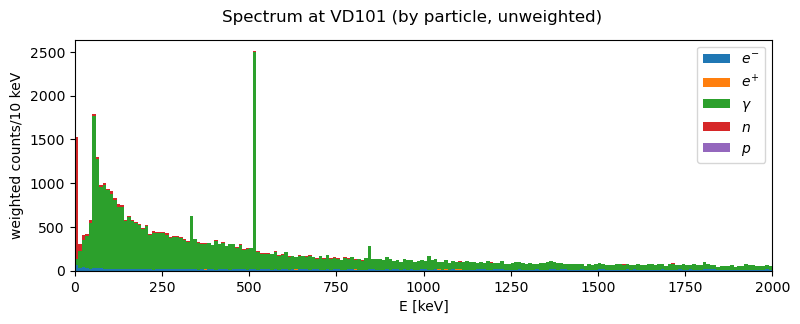

In [17]:
fig, ax = plot_utils.spectra_stacked_particle(df, "Spectrum at VD101 (by particle, unweighted)", None, False)

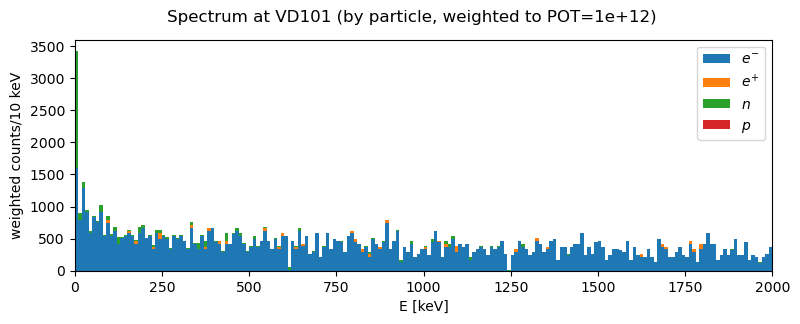

In [18]:
df_nogamma = df.query("pdgId!=22").reset_index()
fig, ax = plot_utils.spectra_stacked_particle(df_nogamma, "Spectrum at VD101 (by particle, weighted to POT=%.0e)"%int(filepath.goal_POT))#, constants.spectramaxbincount)

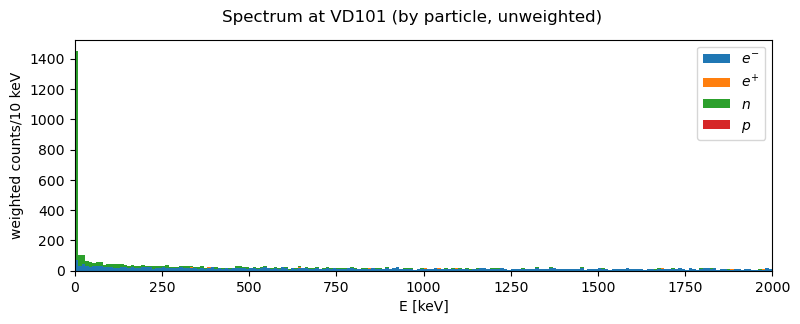

In [19]:
fig, ax = plot_utils.spectra_stacked_particle(df_nogamma, "Spectrum at VD101 (by particle, unweighted)", None, False)